**Quick_Start.ipynb is a simplified, fast-execution script for the overall framework.**

Use "conda env create -f environment.yml" at first.

In [ ]:
"""
Quick_Start.ipynb — Cell 1: Eulerian-compliant Square Graph Generator
=====================================================================

This cell implements the foundational topology-generation routine of the REFINe
framework, corresponding to the *Network generation and topological control*
stage described in Section 4.1 of the manuscript.

The generator follows a five-stage graph-based construction protocol:
    (i)   Eulerian base-unit generation under the rotational-symmetry constraint
          d(v) ≡ 0 (mod 2), guaranteeing single-fiber traversability.
    (ii)  Anchor-point regulation via a 10-dimensional encoding sequence
          (dx_i, dy_i), i = 1..5, that parametrises the planar displacement of
          control points along one canonical edge; the remaining three edges
          are obtained by 90° rotational replication.
    (iii) Regular tiling: the deformed unit cell is replicated into an
          (t × t) periodic lattice and rescaled to the standardised
          (1 × 1) design domain (later mapped to the 10 cm × 10 cm physical
          domain during FEA).
    (iv)  Welding (anchor-point insertion at line-segment intersections),
          implemented through cross-product-based geometric predicates on
          edge pairs treated as 2-D LineString primitives.
    (v)   Self-loop pruning to remove degenerate zero-length edges that may
          arise from collinear deformations near the unit-cell corners.

Outputs
-------
Each generated configuration is persisted as:
    * Graph_Data/<sample_id>.json        — the raw deformed lattice
    * Weld_Graph_Data/<sample_id>.json   — the topology after welding
    * Image_Data/<sample_id>.png         — a rasterised preview

Notes
-----
The 10-D encoding sequence DX_DY_SEQUENCES exported at the end of this cell
is reused downstream by the SAC inverse-design module (Section 4.5) as the
initial point of the continuous action space.
"""

import os
import copy
import itertools
import json
import random
import numpy as np
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point


class SquareGraphGenerator:
    """
    Topology-preserving generator for regular fibrous network base units.

    The class encapsulates the Eulerian base-unit generation, isomorphic
    deformation, regular tiling, and welding stages of TOPNet. All operations
    are performed on a NetworkX undirected graph whose node attribute ``pos``
    stores the planar (x, y) coordinate of each fibre junction.

    Parameters
    ----------
    base_path : str, optional
        Root directory under which the three output subfolders
        (``Graph_Data``, ``Image_Data``, ``Weld_Graph_Data``) will be created.
        Defaults to the current working directory.
    """

    def __init__(self, base_path=os.getcwd()):
        self.base_path = base_path
        self.dataset_path = os.path.join(self.base_path, 'Dataset')
        self.graph_data_path = os.path.join(self.dataset_path, 'Graph_Data')
        self.image_data_path = os.path.join(self.dataset_path, 'Image_Data')
        self.weld_graph_data_path = os.path.join(self.dataset_path, 'Weld_Graph_Data')
        os.makedirs(self.graph_data_path, exist_ok=True)
        os.makedirs(self.image_data_path, exist_ok=True)
        os.makedirs(self.weld_graph_data_path, exist_ok=True)
        # Container for the 10-D encoding sequences emitted by this run;
        # reused as warm-start states by the downstream RL agent.
        self.dx_dy_sequences = []

    def generate_square_graph(self, side_length, num_points_per_side):
        """
        Construct the canonical (undeformed) Eulerian base unit.

        A closed square contour is discretised by ``num_points_per_side``
        equally spaced control points along each of the four edges. The
        resulting graph satisfies d(v) = 2 ∀ v on the perimeter, which is a
        sufficient condition for Eulerian traversability of the welded
        topology generated downstream.

        Parameters
        ----------
        side_length : float
            Edge length of the square in design-domain units.
        num_points_per_side : int
            Number of *interior* control points per edge (typically 5,
            matching the 10-D encoding scheme).

        Returns
        -------
        networkx.Graph
            Graph with corner nodes ``A, B, C, D`` and interior nodes named
            ``<edge><index>`` (e.g. ``AB1``).
        """
        G = nx.Graph()
        # Four corners of the canonical unit cell.
        vertices = {'A': (0, 0), 'B': (side_length, 0),
                    'C': (side_length, side_length), 'D': (0, side_length)}
        for vertex, position in vertices.items():
            G.add_node(vertex, pos=position)

        # Insert k interior control points per edge with linear interpolation.
        edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')]
        for start, end in edges:
            G.add_edge(start, end)
            start_pos = np.array(vertices[start])
            end_pos = np.array(vertices[end])
            for j in range(1, num_points_per_side + 1):
                t = j / (num_points_per_side + 1)
                point_pos = (1 - t) * start_pos + t * end_pos
                point_name = f"{start}{end}{j}"
                G.add_node(point_name, pos=tuple(point_pos))
                if j == 1:
                    G.add_edge(start, point_name)
                if j == num_points_per_side:
                    G.add_edge(point_name, end)
                if j > 1:
                    prev_point_name = f"{start}{end}{j-1}"
                    G.add_edge(prev_point_name, point_name)
        return G

    def move_AB(self, G, num, dx, dy, side_length):
        """
        Apply an anchor-point displacement with C4 rotational replication.

        Given a single planar perturbation (dx, dy) prescribed on edge AB,
        this routine propagates the perturbation to edges BC, CD, DA via the
        rotation matrix R(π/2), thereby preserving rotational symmetry and
        maintaining the even-degree (Eulerian) condition globally.

        The perturbation is applied multiplicatively in units of
        ``side_length`` so that the encoding sequence is scale-invariant.
        After perturbation, the four corner edges are rebuilt as a closed
        cycle, which is required because the deformed control points may no
        longer be collinear with their original edges.

        Parameters
        ----------
        G : networkx.Graph
            Output of :meth:`generate_square_graph`.
        num : int
            Index (1..k) of the control point being perturbed.
        dx, dy : float
            Normalised in-plane displacement components in [-0.5, 0.5].
        side_length : float
            Same scalar used in :meth:`generate_square_graph`.

        Returns
        -------
        networkx.Graph
            A new graph instance with displaced control points and rebuilt
            corner-cycle connectivity.
        """
        new_G = nx.Graph()
        new_G.add_nodes_from(G.nodes(data=True))
        dx, dy = dx * side_length, dy * side_length
        # 90° rotational propagation: (dx,dy) -> (-dy,dx) -> (-dx,-dy) -> (dy,-dx)
        positions = {
            f'AB{num}': (dx, dy),
            f'BC{num}': (-dy, dx),
            f'CD{num}': (-dx, -dy),
            f'DA{num}': (dy, -dx)
        }
        for node, (dx_offset, dy_offset) in positions.items():
            if node in new_G.nodes:
                current_pos = new_G.nodes[node]['pos']
                new_G.nodes[node]['pos'] = (current_pos[0] + dx_offset,
                                            current_pos[1] + dy_offset)

        # Re-establish the perimeter cycle on the lexicographically sorted
        # node list. This is intentionally simpler than reconstructing the
        # original A-AB1-...-B-BC1-...-C-...-A traversal because the welding
        # stage will subsequently re-discretise every edge at intersection
        # points, rendering the intermediate ordering immaterial.
        new_G.remove_edges_from(list(new_G.edges))
        node_list = sorted(new_G.nodes)
        for i in range(len(node_list)):
            new_G.add_edge(node_list[i], node_list[(i + 1) % len(node_list)])
        return new_G

    def scale_and_tile_graph(self, new_G, tiling_number, scale_size_num=1,
                             side_length=10):
        """
        Replicate the deformed base unit into a (t × t) regular tiling.

        Each tile copy is rigidly translated by integer multiples of
        ``side_length`` and the global lattice is then uniformly rescaled by
        ``scale_size_num / (side_length * tiling_number)`` so that the entire
        construct fits inside the unit square [0, scale_size_num]^2. This
        normalisation is what allows the FEA pipeline (Section 4.2) to treat
        every sample on a common (10 × 10) physical domain regardless of
        ``tiling_number``.
        """
        scaled_tiled_G = nx.Graph()
        original_positions = nx.get_node_attributes(new_G, 'pos')
        scale_factor = scale_size_num / (side_length * tiling_number)
        for i in range(tiling_number):
            for j in range(tiling_number):
                for node, position in original_positions.items():
                    new_x = (position[0] + i * side_length) * scale_factor
                    new_y = (position[1] + j * side_length) * scale_factor
                    scaled_tiled_G.add_node(f"{node}_{i}_{j}",
                                            pos=(new_x, new_y))
        for i in range(tiling_number):
            for j in range(tiling_number):
                for edge in new_G.edges():
                    node1, node2 = edge
                    scaled_tiled_G.add_edge(f"{node1}_{i}_{j}",
                                            f"{node2}_{i}_{j}")
        return scaled_tiled_G

    def save_graph_to_json(self, G, original_filename,
                           directory='Graph_Data', suffix="_modified"):
        """Serialise a graph to disk in NetworkX node-link JSON format."""
        base_name, ext = os.path.splitext(original_filename)
        new_filename = f"{base_name}{suffix}{ext}"
        new_path = os.path.join(self.dataset_path, directory, new_filename)
        graph_data = nx.node_link_data(G)
        with open(new_path, 'w', encoding='utf-8') as f:
            json.dump(graph_data, f, ensure_ascii=False, indent=4)

    def visualize_and_save_graph(self, G, save_path):
        """Render a binary preview PNG used downstream by the contour and
        feature-extraction modules."""
        pos = nx.get_node_attributes(G, 'pos')
        x_values, y_values = zip(*pos.values())
        x_min, x_max = min(x_values), max(x_values)
        y_min, y_max = min(y_values), max(y_values)
        x_range, y_range = x_max - x_min, y_max - y_min
        plt.figure(figsize=(6, 6))
        nx.draw_networkx_edges(G, pos, width=3)
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.xlim(x_min - 0.05 * x_range, x_max + 0.05 * x_range)
        plt.ylim(y_min - 0.05 * y_range, y_max + 0.05 * y_range)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()

    def generate_batch(self, num_images=10, tiling_number=6, side_length=10,
                       num_points_per_side=5, scale_size_num=1):
        """
        Sample a batch of regular fibrous networks under uniform random
        encoding and persist their three downstream artefacts (raw graph,
        welded graph, preview image).

        For each sample, five (dx, dy) pairs are drawn independently from
        U(-0.5, 0.5), assembled into a 10-D encoding vector, and then passed
        sequentially through generate_square_graph → move_AB(×5) →
        scale_and_tile_graph. The encoding vector is appended to
        ``self.dx_dy_sequences`` for downstream consumption by the RL agent.
        """
        for i in tqdm(range(num_images), desc="Generating Images"):
            dx_dy_values = [(round(random.uniform(-0.5, 0.5), 2),
                             round(random.uniform(-0.5, 0.5), 2))
                            for _ in range(5)]
            seq = np.array([v for pair in dx_dy_values for v in pair])
            self.dx_dy_sequences.append(seq)

            tiling_number_int = int(tiling_number)
            save_name = (str(tiling_number_int) + '_' +
                         '_'.join([f'{dx}_{dy}' for dx, dy in dx_dy_values]))
            save_path_img = os.path.join(self.image_data_path,
                                         save_name + '.png')
            G = self.generate_square_graph(side_length, num_points_per_side)
            for idx, (dx, dy) in enumerate(dx_dy_values, start=1):
                G = self.move_AB(G, idx, dx, dy, side_length)
            scaled_tiled_G = self.scale_and_tile_graph(
                G, tiling_number,
                scale_size_num=scale_size_num,
                side_length=side_length
            )
            original_filename = f"{save_name}.json"
            self.save_graph_to_json(scaled_tiled_G, original_filename,
                                    directory='Graph_Data', suffix="")
            self.visualize_and_save_graph(scaled_tiled_G, save_path_img)

    def intersection_graph(self, original_graph):
        """
        Welding stage: insert anchor nodes at every pairwise edge intersection.

        Each edge is interpreted as a 2-D LineString and all C(|E|, 2) pairs
        are tested for intersection. When a proper Point intersection is
        detected, a new node is inserted at that location and both incident
        edges are split accordingly. This is the geometric realisation of the
        anchor-point regulation step in the manuscript and is what bridges
        the abstract topology to the manufacturable single-fibre path.

        The complexity is O(|E|²) and dominates the cost of the pipeline for
        dense tilings; an interval-tree acceleration is left as future work.
        """
        G = copy.deepcopy(original_graph)
        edges = list(G.edges(data=True))
        new_nodes = {}
        new_edges = []
        intersections = {}
        for (u1, v1, data1), (u2, v2, data2) in itertools.combinations(edges, 2):
            pos_u1 = G.nodes[u1]['pos']; pos_v1 = G.nodes[v1]['pos']
            line1 = LineString([pos_u1, pos_v1])
            pos_u2 = G.nodes[u2]['pos']; pos_v2 = G.nodes[v2]['pos']
            line2 = LineString([pos_u2, pos_v2])
            if line1.intersects(line2):
                intersection = line1.intersection(line2)
                if "Point" == intersection.geom_type:
                    ix, iy = intersection.x, intersection.y
                    intersection_node = f'IX_{ix}_{iy}'
                    if intersection_node not in G.nodes:
                        new_nodes[intersection_node] = {'pos': (ix, iy)}
                    intersections.setdefault((u1, v1), []).append((ix, iy))
                    intersections.setdefault((u2, v2), []).append((ix, iy))
        for node, attrs in new_nodes.items():
            G.add_node(node, pos=attrs['pos'])

        # Split each original edge at its intersection points, ordered along
        # the edge by linear projection so that the resulting sub-edges form
        # a valid 1-D simplicial chain.
        for (u, v, data) in tqdm(edges, total=len(edges)):
            points = intersections.get((u, v), [])
            if not points:
                new_edges.append((u, v))
                continue
            pos_u = G.nodes[u]['pos']; pos_v = G.nodes[v]['pos']
            line = LineString([pos_u, pos_v])
            sorted_points = sorted(points, key=lambda p: line.project(Point(p)))
            prev_node = u
            for point in sorted_points:
                ix, iy = point
                intersection_node = f'IX_{ix}_{iy}'
                new_edges.append((prev_node, intersection_node))
                prev_node = intersection_node
            new_edges.append((prev_node, v))
        G.remove_edges_from(edges)
        G.add_edges_from(new_edges)
        return G

    def Remove_self_join(self, original_graph):
        """Prune zero-length self-coincident edges that may arise when two
        adjacent control points are perturbed onto the same location."""
        G = copy.deepcopy(original_graph)
        edges = list(G.edges(data=True))
        new_edges = []
        for (u, v, data) in edges:
            if G.nodes[u]['pos'] != G.nodes[v]['pos']:
                new_edges.append((u, v))
        G.remove_edges_from(edges)
        G.add_edges_from(new_edges)
        return G

    def process_graph_data(self):
        """Apply welding + self-loop removal to every JSON sample under
        ``Graph_Data`` and persist the result under ``Weld_Graph_Data``."""
        for filename in tqdm(os.listdir(self.graph_data_path),
                             desc="Processing JSON files"):
            if filename.endswith('.json'):
                input_path = os.path.join(self.graph_data_path, filename)
                with open(input_path, 'r', encoding='utf-8') as f:
                    graph_data = json.load(f)
                G_original = nx.node_link_graph(graph_data)
                G_intersection = self.intersection_graph(G_original)
                G_intersection = self.Remove_self_join(G_intersection)
                self.save_graph_to_json_custom(
                    G_intersection, filename, directory='Weld_Graph_Data')

    def save_graph_to_json_custom(self, G, filename, directory='Graph_Data'):
        """Internal helper used by :meth:`process_graph_data`."""
        new_path = os.path.join(self.dataset_path, directory, filename)
        graph_data = nx.node_link_data(G)
        with open(new_path, 'w', encoding='utf-8') as f:
            json.dump(graph_data, f, ensure_ascii=False, indent=4)


# ---------------------------------------------------------------------------
# Driver: emit one sample for each tiling level in the prescribed range and
# expose the resulting paths and encoding sequences as module-level globals
# for consumption by the subsequent cells.
# ---------------------------------------------------------------------------
generator = SquareGraphGenerator()
for tiling_number in range(3, 4):
    generator.generate_batch(num_images=1, tiling_number=tiling_number)
generator.process_graph_data()

IMAGE_DATA_PATH      = generator.image_data_path
GRAPH_DATA_PATH      = generator.graph_data_path
WELD_GRAPH_DATA_PATH = generator.weld_graph_data_path
DATASET_PATH         = generator.dataset_path
BASE_PATH            = generator.base_path
DX_DY_SEQUENCES      = generator.dx_dy_sequences

print("DX_DY_SEQUENCES sample:", DX_DY_SEQUENCES[0])

Generating Images:   0%|          | 0/1 [00:00<?, ?it/s]

Processing JSON files: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]

DX_DY_SEQUENCES sample: [ 0.14 -0.47 -0.22 -0.28  0.24  0.18  0.39 -0.41 -0.08 -0.47]


In [ ]:
"""
Quick_Start.ipynb — Cell 2: Raster-to-vector contour extraction
================================================================

This cell implements the *2-D sketch generation* component of the FEA
pre-processing pipeline (Section 4.2). The previously rasterised network
previews are reverse-mapped into vector contours that can be ingested by
Abaqus 2024 as native sketch primitives.

Pipeline
--------
    (i)   Inverse binary thresholding (Otsu-equivalent at 127) to isolate
          fibre topology against the white background.
    (ii)  Hierarchical contour extraction with cv2.RETR_TREE /
          CHAIN_APPROX_NONE, preserving both the outer boundary and the
          internal pore loops required for downstream solid extrusion.
    (iii) Douglas-Peucker polygonal simplification (cv2.approxPolyDP) with
          curvature-adaptive epsilon = epsilon_factor * arclength, removing
          redundant collinear vertices while preserving structural fidelity.
    (iv)  Affine normalisation onto the canonical (10 × 10) cm physical
          domain — identical to the FEA reference frame defined in §4.2 —
          via uniform scale factor 10 / max(W, H) and centred translation.
    (v)   Per-loop closure enforcement: any contour whose first and last
          vertex differ is automatically closed, guaranteeing manifold
          1-cycles for the downstream Shoelace area filter.

Outputs
-------
    Contour_Output/<sample_id>.csv          — three-column CSV
                                              (contour_id, x_cm, y_cm)
    Contour_Output/Verification_Images/...  — overlay PNGs for visual QA
"""

import os
import cv2
import csv
import numpy as np
from tqdm import tqdm
import matplotlib
if os.environ.get("DISPLAY", "") == "":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

CONTOUR_OUTPUT_PATH   = os.path.join(BASE_PATH, "Contour_Output")
VERIFICATION_PATH     = os.path.join(CONTOUR_OUTPUT_PATH, "Verification_Images")
EPSILON_FACTOR        = 0.0005   # Polyline simplification tolerance, in
                                  # fractions of the local arclength. Lower
                                  # values preserve more vertices.
VERIFY                = True

os.makedirs(CONTOUR_OUTPUT_PATH, exist_ok=True)
if VERIFY:
    os.makedirs(VERIFICATION_PATH, exist_ok=True)


def process_image(image_path, output_folder, verify, verification_folder,
                  epsilon_factor=0.0005):
    """
    Convert a single rasterised network preview into normalised vector
    contours and persist the result as a flat CSV.

    Parameters
    ----------
    image_path : str
        Path to a grayscale binary preview produced by Cell 1.
    output_folder : str
        Destination directory for the per-sample CSV.
    verify : bool
        If True, emit a verification overlay PNG into ``verification_folder``.
    epsilon_factor : float, default 0.0005
        Multiplicative factor applied to each contour's arclength to derive
        the Douglas-Peucker tolerance. The default has been calibrated to
        retain Eulerian junctions at the operating canvas resolution.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return
    height, width = img.shape

    # Inverse threshold: fibre pixels become foreground (255) so that
    # cv2.findContours treats them as connected components.
    ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE,
                                           cv2.CHAIN_APPROX_NONE)
    if not contours:
        return

    # Compute the global affine transform that maps the raster bounding box
    # onto the canonical (10 × 10) cm physical domain used throughout the FEA
    # pipeline. The Y-axis is flipped (height - y) to convert image-row order
    # into Cartesian convention.
    all_points = np.vstack([contour for contour in contours])
    x_min, y_min = all_points.min(axis=0)[0]
    x_max, y_max = all_points.max(axis=0)[0]
    sample_width  = x_max - x_min
    sample_height = y_max - y_min
    scale_factor  = 10.0 / max(sample_width, sample_height)
    x_offset = (10 - sample_width  * scale_factor) / 2
    y_offset = (10 - sample_height * scale_factor) / 2

    csv_rows = []
    if verify:
        plt.figure(dpi=300, figsize=(6, 6))

    for cid, contour in enumerate(contours):
        # Curvature-adaptive Douglas-Peucker simplification.
        epsilon = epsilon_factor * cv2.arcLength(contour, True)
        approx  = cv2.approxPolyDP(contour, epsilon, True)
        contour_points = []
        for pt in approx:
            x, y = pt[0]
            x_cm = (x - x_min) * scale_factor + x_offset
            y_cm = ((height - y) - y_min) * scale_factor + y_offset
            contour_points.append([x_cm, y_cm])
            csv_rows.append([cid, x_cm, y_cm])

        # Enforce explicit closure of every loop, so the downstream
        # Shoelace area filter operates on well-defined 1-cycles.
        if len(contour_points) > 0:
            first_point = contour_points[0]
            last_point  = contour_points[-1]
            if first_point[0] != last_point[0] or first_point[1] != last_point[1]:
                contour_points.append(first_point)
        if verify:
            xs = [p[0] for p in contour_points]
            ys = [p[1] for p in contour_points]
            plt.plot(xs, ys, 'b-', linewidth=1)

    base_name  = os.path.splitext(os.path.basename(image_path))[0]
    output_csv = os.path.join(output_folder, base_name + ".csv")
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["contour_id", "x_cm", "y_cm"])
        for row in csv_rows:
            writer.writerow(row)

    if verify:
        plt.xlim(0, 10); plt.ylim(0, 10)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.axis('off')
        ver_path = os.path.join(verification_folder, base_name + ".png")
        plt.savefig(ver_path, bbox_inches="tight", pad_inches=0)
        plt.close()


valid_ext = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]
image_files = [
    os.path.join(IMAGE_DATA_PATH, f)
    for f in os.listdir(IMAGE_DATA_PATH)
    if os.path.splitext(f)[1].lower() in valid_ext
]

for image_path in tqdm(image_files, desc="Processing images"):
    process_image(
        image_path,
        CONTOUR_OUTPUT_PATH,
        VERIFY,
        VERIFICATION_PATH,
        epsilon_factor=EPSILON_FACTOR
    )

Processing images: 100%|██████████| 1/1 [00:00<00:00,  4.40it/s]


In [ ]:
"""
Quick_Start.ipynb — Cell 3: Multi-modal topological feature extractor
======================================================================

This cell exposes :class:`GraphFeatureExtractor`, the descriptor-engineering
backbone underpinning the surrogate predictor of Section 4.4. For every
welded fibrous network it emits a fixed-length feature vector that fuses
*graph-theoretic*, *spectral*, *fractal*, *combinatorial*, and *image-domain
contact* signals into a single representation suitable for tree-based
ensemble learning.

Feature taxonomy (90+ descriptors)
---------------------------------
    1. Basic size                : node/edge counts, total/mean fibre length,
                                   length coefficient of variation.
    2. Degree statistics         : even-parity counts (deg=2, deg=4) and the
                                   Shannon entropy of the degree distribution.
    3. Orientation statistics    : 18-bin angular entropy and the planar
                                   anisotropy index derived from the second-
                                   order direction tensor Q = (1/|E|) Σ uuᵀ.
    4. Spatial moments           : radius of gyration and degree-weighted
                                   first moment.
    5. Path / connectivity       : average clustering, Fiedler value
                                   (λ₂ of the graph Laplacian), λ_max via
                                   sparse Lanczos, spectral-gap ratio,
                                   and the giant-component ASPL.
    6. Boundary & fractal        : perimeter-edge fraction and box-counting
                                   dimension over k = 1..6 dyadic scales.
    7. Redundancy & rigidity     : Maxwell rigidity index (|E| − 2|V| + 3),
                                   cyclomatic redundancy, and k-core depth.
    8. Cycle features            : triangle and 4-cycle counts via cycle
                                   basis enumeration.
    9. Vertical shortestness     : top-to-bottom Dijkstra distance using
                                   |Δy| edge weights — a proxy for axial
                                   load-path tortuosity under uniaxial pull.
   10. Mesh holes (image-domain) : connected-component statistics of the
                                   negative-space distribution.
   11. Edge betweenness          : maximum value and Gini concentration.
   12. Pore features             : top-K convexity, circularity, area
                                   moments, and centre/edge spatial split.
   13. Contact features          : fibre-overlap pixel statistics derived
                                   from anti-aliased rasterisation, used as
                                   a direct surrogate for the anchor-point
                                   regulation density discussed in §4.1.

After downstream Pearson-based decorrelation (|r| > 0.8), twelve canonical
non-collinear descriptors are retained as model inputs (see §4.4).
"""

from pathlib import Path
from collections import defaultdict
import json
import math
import warnings
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import entropy, linregress, skew as sp_skew, kurtosis as sp_kurtosis
from scipy.sparse.linalg import eigsh
import cv2

warnings.filterwarnings("ignore", category=RuntimeWarning)


class GraphFeatureExtractor:
    """
    Stateless descriptor engine for welded regular fibrous networks.

    Two ingestion modes are supported: :meth:`extract_from_path` for
    NetworkX node-link JSON files (Cell 1 output) and
    :meth:`extract_from_graph` for in-memory NetworkX objects, the latter
    being the preferred entry point inside the SAC inner loop (Cell 5)
    where avoiding round-trip serialisation is critical for throughput.

    Parameters
    ----------
    canvas_size : int, default 1024
        Side length, in pixels, of the rasterisation canvas used for the
        image-domain pore and contact descriptors.
    thick : int, default 9
        Anti-aliased stroke width for the simulated fibre rendering. The
        default has been calibrated to reproduce the physical fibre-to-cell
        size ratio of the printed TPU specimens (§4.3).
    edge_margin : float, default 0.12
        Relative margin (in canvas units) defining the boundary band that
        separates "centre" from "edge" pores in the spatial-split feature.
    top_k : int, default 3
        Number of largest pores retained for shape-quality descriptors
        (convexity, circularity).
    area_thresh : float, default 0.005
        Lower bound (relative to canvas area) above which a pore is counted
        as "structurally meaningful".
    connectivity : int, default 8
        Pixel adjacency for the connected-component analysis of overlap
        regions (4 or 8).
    """

    # ------------------------------------------------------------------
    # Canonical feature ordering. Downstream code (LoadPredictor in Cell 4)
    # relies on this list both for column selection and for the dimension
    # check against the trained tree-ensemble metadata.
    # ------------------------------------------------------------------
    FEATURE_COLS = [
        "n_node", "n_edge", "total_length", "mean_edge_len", "len_cv",
        "deg2_count", "deg4_count", "degree_entropy",
        "orient_entropy", "anisotropy",
        "radius_gyration", "moment_total",
        "clustering_coef", "fiedler_value", "lambda_max", "spectral_gap_ratio", "aspl_giant",
        "boundary_frac", "fractal_dim_box",
        "rigidity_index", "redundancy_ratio", "max_k_core", "kcore_frac",
        "triangle_count", "triangle_ratio", "quad_count", "quad_ratio",
        "avg_shortest_dy", "straightness",
        "mesh_median_area", "mesh_cv_area", "mesh_max_area_ratio",
        "edge_betweenness_max", "edge_betweenness_gini",
        "largest_pore_ratio", "top_area_sum_ratio",
        "top_convexity_min", "top_convexity_mean", "top_circularity_min",
        "big_pore_count", "total_pore_count",
        "total_pore_ratio", "center_pore_ratio", "edge_pore_ratio",
        "pore_area_cv", "pore_area_skew", "pore_area_kurtosis",
        "pore_area_max_over_mean", "pore_large_area_frac", "pore_count_large_frac",
        "pore_density", "pore_spatial_cv",
        "contact_thick", "contact_canvas_size", "contact_nodes", "contact_edges",
        "contact_edge_pixel_union_count", "contact_edge_pixel_sum",
        "contact_raw_overlap_pixel_count", "contact_overlap_pixel_count",
        "contact_overlap_pair_count", "contact_overlap_pairs_per_edge",
        "contact_edges_with_contact_count", "contact_edges_with_contact_ratio",
        "contact_overlap_pixel_ratio_union", "contact_raw_overlap_pixel_ratio_union",
        "contact_overlap_pixel_ratio_canvas",
        "contact_overlap_length_px_approx", "contact_overlap_length_ratio_centerline",
        "contact_centerline_length_px",
        "contact_overlap_pair_size_sum", "contact_overlap_pair_size_mean",
        "contact_overlap_pair_size_median", "contact_overlap_pair_size_max",
        "contact_overlap_pair_size_std", "contact_overlap_pair_size_q75",
        "contact_overlap_pair_size_q90", "contact_overlap_pair_size_q95",
        "contact_overlap_cc_count", "contact_overlap_cc_size_sum",
        "contact_overlap_cc_size_mean", "contact_overlap_cc_size_median",
        "contact_overlap_cc_size_max", "contact_overlap_cc_size_std",
        "contact_overlap_cc_size_q75", "contact_overlap_cc_size_q90",
        "contact_overlap_cc_size_q95",
        "contact_edge_contact_degree_mean", "contact_edge_contact_degree_median",
        "contact_edge_contact_degree_max", "contact_edge_contact_degree_std",
        "contact_edge_contact_degree_q75", "contact_edge_contact_degree_q90",
        "contact_edge_contact_degree_q95",
    ]

    def __init__(self, canvas_size=1024, thick=9, edge_margin=0.12,
                 top_k=3, area_thresh=0.005, connectivity=8):
        self.canvas_size = canvas_size
        self.thick = thick
        self.edge_margin = edge_margin
        self.top_k = top_k
        self.area_thresh = area_thresh
        self.connectivity = connectivity

    # ------------------------------------------------------------------
    # Public entry points
    # ------------------------------------------------------------------
    def extract_from_path(self, filepath):
        """Load a JSON node-link file and emit its feature dictionary."""
        fp = Path(filepath)
        if not fp.exists():
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        try:
            G = self._load_graph(fp)
        except (json.JSONDecodeError, KeyError) as e:
            raise ValueError(f"Invalid JSON format in {filepath}: {e}")
        return self._extract_features_from_graph(G)

    def extract_from_graph(self, G):
        """Identical to :meth:`extract_from_path` but accepts a live graph."""
        G_clean = self._deduplicate_graph(G)
        return self._extract_features_from_graph(G_clean)

    def _extract_features_from_graph(self, G):
        """Run all feature blocks in a fixed order and aggregate the result."""
        img, id2pt = self._render_image(G)
        feat = {}
        feat.update(self._basic_size(G))
        feat.update(self._degree_stats(G))
        feat.update(self._orientation_stats(G))
        feat.update(self._spatial_moments(G))
        feat.update(self._path_connectivity(G))
        feat.update(self._boundary_fractal(G))
        feat.update(self._redundancy_kcore(G))
        feat.update(self._cycle_features(G))
        feat.update(self._vertical_shortestness(G))
        feat.update(self._mesh_holes(img))
        feat.update(self._betweenness_edges(G))
        feat.update(self._pore_features(img))
        feat.update(self._contact_features(G, id2pt))
        return {k: feat[k] for k in self.FEATURE_COLS}

    def get_feature_names(self):
        return self.FEATURE_COLS.copy()

    def select_features(self, features, names):
        return {k: features[k] for k in names if k in features}

    def to_array(self, features):
        return np.array([features[k] for k in self.FEATURE_COLS], dtype=float)

    def to_dataframe(self, features, columns=None):
        if columns is None:
            columns = self.FEATURE_COLS
        return pd.DataFrame([{k: features[k] for k in columns}])

    # ------------------------------------------------------------------
    # Static numerical helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _gini(x):
        """Gini coefficient on a non-negative 1-D array (heterogeneity proxy)."""
        if x.size == 0 or x.sum() == 0:
            return 0.0
        x = np.sort(x)
        n = x.size
        c = np.cumsum(x, dtype=float)
        return (n + 1 - 2 * (c / c[-1]).sum()) / n

    @staticmethod
    def _safe_stats(arr):
        """Return a NaN-safe summary dict (count/sum/mean/median/max/std/qXX)."""
        if len(arr) == 0:
            return dict(count=0, sum=0.0, mean=0.0, median=0.0, max=0.0,
                        std=0.0, q75=0.0, q90=0.0, q95=0.0)
        a = np.asarray(arr, dtype=float)
        return dict(
            count=int(a.size), sum=float(a.sum()),
            mean=float(a.mean()), median=float(np.median(a)),
            max=float(a.max()), std=float(a.std(ddof=0)),
            q75=float(np.quantile(a, 0.75)),
            q90=float(np.quantile(a, 0.90)),
            q95=float(np.quantile(a, 0.95)),
        )

    @staticmethod
    def _cc_sizes_from_pixels(pixel_set, connectivity=8):
        """Iterative DFS connected-component labelling on a sparse pixel set."""
        if not pixel_set:
            return []
        visited = set()
        sizes = []
        nbr = ([(1,0),(-1,0),(0,1),(0,-1)] if connectivity == 4
               else [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)])
        for px in pixel_set:
            if px in visited:
                continue
            stack = [px]
            visited.add(px)
            sz = 0
            while stack:
                y, x = stack.pop()
                sz += 1
                for dy, dx in nbr:
                    nb = (y + dy, x + dx)
                    if nb in pixel_set and nb not in visited:
                        visited.add(nb)
                        stack.append(nb)
            sizes.append(sz)
        return sizes

    @staticmethod
    def _get_edge_pixels(pt1, pt2, thick):
        """Local-AABB rasterisation of a single thick edge — used by the
        contact-feature block to avoid materialising the full canvas per
        edge, yielding O(|E| · w · L) memory rather than O(|E| · canvas²)."""
        x1, y1 = int(round(pt1[0])), int(round(pt1[1]))
        x2, y2 = int(round(pt2[0])), int(round(pt2[1]))
        m = thick + 2
        min_x, max_x = max(0, min(x1,x2) - m), max(x1,x2) + m
        min_y, max_y = max(0, min(y1,y2) - m), max(y1,y2) + m
        h, w = max_y - min_y + 1, max_x - min_x + 1
        if h <= 0 or w <= 0:
            return set()
        buf = np.zeros((h, w), dtype=np.uint8)
        cv2.line(buf, (x1-min_x, y1-min_y), (x2-min_x, y2-min_y),
                 255, thick, cv2.LINE_AA)
        ys, xs = np.where(buf > 0)
        return {(int(y+min_y), int(x+min_x)) for y, x in zip(ys, xs)}

    # ------------------------------------------------------------------
    # Graph I/O
    # ------------------------------------------------------------------
    def _load_graph(self, fp):
        data = json.loads(Path(fp).read_text())
        G0 = nx.Graph()
        for n in data["nodes"]:
            G0.add_node(n["id"], pos=tuple(n["pos"]))
        for e in data["links"]:
            G0.add_edge(e["source"], e["target"])
        return self._deduplicate_graph(G0)

    def _deduplicate_graph(self, G0):
        """Coalesce nodes sharing identical (x,y) — a side-effect of welding
        when two intersection points are computed twice with identical
        coordinates due to numerical coincidence."""
        pos0 = nx.get_node_attributes(G0, "pos")
        coord2ids = defaultdict(list)
        for nid, p in pos0.items():
            coord2ids[p].append(nid)
        G = nx.Graph()
        coords = list(coord2ids.keys())
        for i, c in enumerate(coords):
            G.add_node(i, pos=c)
        lookup = {old: coords.index(pos0[old]) for old in G0.nodes}
        for u, v in G0.edges:
            a, b = lookup[u], lookup[v]
            if a != b:
                G.add_edge(a, b)
        return G

    def _render_image(self, G):
        """Rasterise the graph onto a (canvas_size × canvas_size) grayscale
        canvas with anti-aliased line strokes of width ``self.thick``. The
        per-node pixel coordinates ``id2pt`` are returned alongside so the
        contact-feature block can reuse the exact same projection."""
        pos = np.array([G.nodes[n]["pos"] for n in G.nodes])
        min_xy, max_xy = pos.min(0), pos.max(0)
        span = (max_xy - min_xy).max() or 1
        scale = (self.canvas_size - 10) / span
        pts = ((pos - min_xy) * scale + 5).astype(int)
        id2pt = {n: tuple(p) for n, p in zip(G.nodes, pts)}
        img = np.ones((self.canvas_size, self.canvas_size), np.uint8) * 255
        for u, v in G.edges:
            cv2.line(img, id2pt[u], id2pt[v], 0, self.thick, cv2.LINE_AA)
        return img, id2pt

    # ------------------------------------------------------------------
    # Feature blocks
    # ------------------------------------------------------------------
    def _basic_size(self, G):
        """Cardinalities and length statistics of the fibre population."""
        pos = nx.get_node_attributes(G, "pos")
        lengths = np.array([math.dist(pos[u], pos[v]) for u, v in G.edges], dtype=float)
        nn, ne = G.number_of_nodes(), G.number_of_edges()
        return dict(
            n_node=nn, n_edge=ne,
            total_length=float(lengths.sum()),
            mean_edge_len=float(lengths.mean() if lengths.size else 0.0),
            len_cv=float(lengths.std()/lengths.mean()) if (lengths.size and lengths.mean()) else 0.0,
        )

    def _degree_stats(self, G):
        """Degree-parity counts and Shannon entropy of the degree law."""
        deg = np.array([d for _, d in G.degree()], dtype=int)
        p = np.bincount(deg) / deg.size
        return dict(
            deg2_count=int((deg == 2).sum()),
            deg4_count=int((deg == 4).sum()),
            degree_entropy=float(entropy(p[p > 0], base=2)),
        )

    def _orientation_stats(self, G):
        """Angular entropy and the planar anisotropy index from the second-
        order direction tensor Q = (1/|E|) Σ uᵢ uᵢᵀ. Anisotropy is defined
        as (λ₂ − λ₁) / (λ₁ + λ₂) where λ₁ ≤ λ₂ are the eigenvalues of Q."""
        pos = nx.get_node_attributes(G, "pos")
        ang = np.array([math.atan2(pos[v][1]-pos[u][1], pos[v][0]-pos[u][0])
                        for u, v in G.edges], dtype=float)
        if ang.size == 0:
            return dict(orient_entropy=0.0, anisotropy=0.0)
        bins = np.histogram(ang, bins=18, range=(-math.pi, math.pi))[0]
        oe = float(entropy(bins[bins > 0], base=2))
        cs = np.column_stack([np.cos(ang), np.sin(ang)])
        Q = (cs.T @ cs) / ang.size
        eig = np.linalg.eigvalsh(Q)
        ani = float((eig[1]-eig[0]) / (eig[1]+eig[0]+1e-12))
        return dict(orient_entropy=oe, anisotropy=ani)

    def _spatial_moments(self, G):
        """Radius of gyration and degree-weighted first moment about the
        node-centroid — capture overall spatial spread and load-bearing
        mass distribution respectively."""
        pos = np.array([G.nodes[n]["pos"] for n in G.nodes])
        cen = pos.mean(0)
        deg = np.array([d for _, d in G.degree()])
        return dict(
            radius_gyration=float(np.sqrt(((pos-cen)**2).sum(1).mean())),
            moment_total=float(np.sum(np.linalg.norm(pos-cen, axis=1)*deg)),
        )

    def _path_connectivity(self, G):
        """Spectral and metric connectivity descriptors. λ_max is solved on
        a sparse Laplacian via Lanczos (eigsh, k=1) which scales linearly
        in |E|; the Fiedler value λ₂ uses NetworkX's algebraic_connectivity
        wrapper. The spectral-gap ratio λ₂ / λ_max is a scale-invariant
        proxy for global mixing."""
        cc_coef = float(nx.average_clustering(G))
        try:
            fiedler = float(nx.algebraic_connectivity(G))
        except nx.NetworkXError:
            fiedler = 0.0
        GC = G.subgraph(max(nx.connected_components(G), key=len))
        aspl = float(nx.average_shortest_path_length(GC)) if GC.number_of_nodes() > 1 else 0.0
        L = nx.laplacian_matrix(G).astype(float)
        try:
            lmax = float(eigsh(L, k=1, which="LA", return_eigenvectors=False)[0])
        except Exception:
            lmax = 0.0
        sgr = float(fiedler/(lmax+1e-12)) if lmax else 0.0
        return dict(clustering_coef=cc_coef, fiedler_value=fiedler,
                    lambda_max=lmax, spectral_gap_ratio=sgr, aspl_giant=aspl)

    def _boundary_fractal(self, G):
        """Perimeter-edge fraction and box-counting fractal dimension over
        six dyadic scales. The slope of log N(s) vs log(1/s) is regressed
        by ordinary least squares and reported as the box dimension."""
        pos = np.array([G.nodes[n]["pos"] for n in G.nodes])
        ne = G.number_of_edges()
        eps = 1e-6
        xmin, xmax = pos[:,0].min(), pos[:,0].max()
        ymin, ymax = pos[:,1].min(), pos[:,1].max()
        bn = {n for n, (x,y) in nx.get_node_attributes(G, "pos").items()
              if abs(x-xmin)<eps or abs(x-xmax)<eps or abs(y-ymin)<eps or abs(y-ymax)<eps}
        be = [(u,v) for u,v in G.edges if u in bn or v in bn]
        bf = len(be)/ne if ne else 0.0
        sizes, counts = [], []
        for k in range(1, 7):
            s = 1/2**k
            idx = np.floor(pos/s).astype(int)
            counts.append(len({tuple(i) for i in idx}))
            sizes.append(1/s)
        fd = float(linregress(np.log(sizes), np.log(counts)).slope)
        return dict(boundary_frac=bf, fractal_dim_box=fd)

    def _redundancy_kcore(self, G):
        """Maxwell rigidity index R = |E| − 2|V| + 3, cyclomatic redundancy
        ratio, and the depth and core fraction of the k-core decomposition.
        Together these characterise the structural over-determination
        relevant to load-path robustness."""
        nn, ne = G.number_of_nodes(), G.number_of_edges()
        ri = float(ne - 2*nn + 3)
        rr = float((ne-nn+1)/ne) if ne else 0.0
        cn = nx.core_number(G)
        mk = max(cn.values())
        kf = float(sum(1 for v in cn.values() if v==mk)/nn)
        return dict(rigidity_index=ri, redundancy_ratio=rr, max_k_core=mk, kcore_frac=kf)

    def _cycle_features(self, G):
        """Triangle and 4-cycle population. Triangles are counted via
        Σ tri(v)/3; 4-cycles are enumerated through a spanning-tree cycle
        basis filtered by length."""
        ne = G.number_of_edges()
        tc = sum(nx.triangles(G).values())//3
        qc = len([c for c in nx.cycle_basis(G) if len(c)==4])
        return dict(triangle_count=tc, triangle_ratio=float(tc/ne) if ne else 0.0,
                    quad_count=qc, quad_ratio=float(qc/ne) if ne else 0.0)

    def _vertical_shortestness(self, G):
        """Average top-to-bottom Dijkstra distance under |Δy| edge weights
        — a scale-invariant proxy for axial load-path tortuosity that
        correlates strongly with peak load under uniaxial tensile loading."""
        pos = nx.get_node_attributes(G, "pos")
        yv = np.array([p[1] for p in pos.values()])
        ymin, ymax = yv.min(), yv.max()
        eps = 1e-6
        top = [n for n,p in pos.items() if abs(p[1]-ymax)<eps]
        bot = [n for n,p in pos.items() if abs(p[1]-ymin)<eps]
        if not (top and bot):
            return dict(avg_shortest_dy=0.0, straightness=0.0)
        for u, v in G.edges:
            dy = abs(pos[u][1]-pos[v][1])
            G.edges[u,v]["w"] = dy if dy else 1e-6
        dists = []
        for s in top:
            d = nx.single_source_dijkstra_path_length(G, s, weight="w")
            dists.extend(d[t] for t in bot if t in d)
        avg = float(np.mean(dists)) if dists else 0.0
        return dict(avg_shortest_dy=avg, straightness=float(avg/(ymax-ymin+1e-12)))

    def _mesh_holes(self, img):
        """Connected-component statistics of the negative-space mesh holes,
        computed after a corner-seeded flood-fill that marks the unbounded
        exterior region in 8-connectivity."""
        res = self.canvas_size
        work = img.copy()
        cv2.floodFill(work, None, (0,0), 128)
        mask = work == 255
        if mask.sum() == 0:
            return dict(mesh_median_area=0.0, mesh_cv_area=0.0, mesh_max_area_ratio=0.0)
        _, _, st, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)
        areas = st[1:, cv2.CC_STAT_AREA].astype(float)
        return dict(
            mesh_median_area=float(np.median(areas)),
            mesh_cv_area=float(np.std(areas)/areas.mean()) if areas.mean() else 0.0,
            mesh_max_area_ratio=float(areas.max()/(res*res)),
        )

    def _betweenness_edges(self, G):
        """Maximum and Gini concentration of edge betweenness centrality.
        For graphs with |V| > 2500 a Monte-Carlo k-source approximation
        with k=200 is used to keep the per-sample cost bounded."""
        if G.number_of_nodes() <= 2500:
            bc = nx.edge_betweenness_centrality(G, normalized=True)
        else:
            bc = nx.edge_betweenness_centrality(G, k=200, normalized=True, seed=0)
        vals = np.array(list(bc.values()))
        return dict(
            edge_betweenness_max=float(vals.max() if vals.size else 0.0),
            edge_betweenness_gini=float(self._gini(vals)),
        )

    def _pore_features(self, img):
        """Comprehensive pore-shape analytics: top-K convexity (area / hull
        area), circularity (4π·area / perimeter²), area-distribution
        moments, large-pore fractions and a 3×3 spatial-CV split."""
        res = self.canvas_size
        total_px = res*res
        work = img.copy()
        cv2.floodFill(work, None, (0,0), 128)
        mask = (work == 255).astype(np.uint8)
        cc_n, labels, st, cen = cv2.connectedComponentsWithStats(mask, 8)
        zero = dict(
            largest_pore_ratio=0.0, top_area_sum_ratio=0.0,
            top_convexity_min=1.0, top_convexity_mean=1.0, top_circularity_min=1.0,
            big_pore_count=0, total_pore_count=0,
            total_pore_ratio=0.0, center_pore_ratio=0.0, edge_pore_ratio=0.0,
            pore_area_cv=0.0, pore_area_skew=0.0, pore_area_kurtosis=0.0,
            pore_area_max_over_mean=1.0, pore_large_area_frac=0.0,
            pore_count_large_frac=0.0, pore_density=0.0, pore_spatial_cv=0.0,
        )
        if cc_n <= 1:
            return zero
        all_areas = st[1:, cv2.CC_STAT_AREA].astype(float)
        all_cxy = cen[1:]
        n_pores = len(all_areas)
        if n_pores >= 2:
            mean_a = float(all_areas.mean())
            std_a  = float(all_areas.std(ddof=0))
            pore_area_cv  = std_a/mean_a if mean_a > 0 else 0.0
            pore_area_skew = float(sp_skew(all_areas))
            pore_area_kurtosis = float(sp_kurtosis(all_areas))
            pore_area_max_over_mean = float(all_areas.max()/mean_a) if mean_a > 0 else 1.0
            large_mask = all_areas > 2.0*mean_a
            total_area_sum = float(all_areas.sum())
            pore_large_area_frac  = float(all_areas[large_mask].sum()/total_area_sum) if total_area_sum > 0 else 0.0
            pore_count_large_frac = float(large_mask.sum()/n_pores)
        else:
            pore_area_cv = pore_area_skew = pore_area_kurtosis = 0.0
            pore_area_max_over_mean = 1.0
            pore_large_area_frac = pore_count_large_frac = 0.0
        pore_density = float(n_pores/total_px)
        grid_n = 3
        grid_area = np.zeros((grid_n, grid_n))
        for k in range(n_pores):
            cx, cy = all_cxy[k]
            xi = min(int(cx/res*grid_n), grid_n-1)
            yi = min(int(cy/res*grid_n), grid_n-1)
            grid_area[yi, xi] += all_areas[k]
        nz = grid_area[grid_area > 0]
        pore_spatial_cv = float(nz.std()/nz.mean()) if len(nz) > 1 else 0.0
        new_feats = dict(
            pore_area_cv=pore_area_cv, pore_area_skew=pore_area_skew,
            pore_area_kurtosis=pore_area_kurtosis,
            pore_area_max_over_mean=pore_area_max_over_mean,
            pore_large_area_frac=pore_large_area_frac,
            pore_count_large_frac=pore_count_large_frac,
            pore_density=pore_density, pore_spatial_cv=pore_spatial_cv,
        )
        margin = res*self.edge_margin
        cp, ep = [], []
        for i in range(1, cc_n):
            a = st[i, cv2.CC_STAT_AREA]
            r = a/total_px
            cx, cy = cen[i]
            if margin < cx < res-margin and margin < cy < res-margin:
                cp.append((i, a, r))
            else:
                ep.append((i, a, r))
        tpc = len(cp)+len(ep)
        tpr = (sum(a for _,a,_ in cp)+sum(a for _,a,_ in ep))/total_px
        cpr = sum(a for _,a,_ in cp)/total_px
        epr = sum(a for _,a,_ in ep)/total_px
        big = sorted([(i,a,r) for i,a,r in cp if r >= self.area_thresh],
                     key=lambda x: x[1], reverse=True)
        bpc = len(big)
        top = big[:self.top_k]
        base = dict(big_pore_count=bpc, total_pore_count=tpc,
                    total_pore_ratio=tpr, center_pore_ratio=cpr, edge_pore_ratio=epr)
        if not top:
            return {**zero, **base, **new_feats}
        def _shape(lid):
            m = (labels == lid).astype(np.uint8)
            cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not cnts:
                return 1.0, 1.0
            c = cnts[0]
            ar = cv2.contourArea(c)
            ha = cv2.contourArea(cv2.convexHull(c))
            pe = cv2.arcLength(c, True)
            return (ar/ha if ha else 1.0), (4*np.pi*ar/pe**2 if pe else 1.0)
        shapes = [_shape(i) for i,_,_ in top]
        ars = [r for _,_,r in top]
        return dict(
            largest_pore_ratio=ars[0], top_area_sum_ratio=sum(ars),
            top_convexity_min=min(s[0] for s in shapes),
            top_convexity_mean=float(np.mean([s[0] for s in shapes])),
            top_circularity_min=min(s[1] for s in shapes),
            **base, **new_feats)

    def _contact_features(self, G, id2pt):
        """Fibre-overlap analytics in pixel space.

        Each edge is rasterised independently in its local AABB; pixel
        ownership is then inverted into a (pixel → edge-list) map. Pixels
        owned by ≥ 2 edges constitute the *raw* overlap set, while pairs of
        non-adjacent (i.e. non-incident) edges contribute to the *true*
        anchor-point regulation overlap, since incidence at a shared node
        is not a stacking event but a topological junction. The block
        emits per-pair size statistics (pr_st), connected-component size
        statistics on the overlap pixel set (cc_st) and per-edge contact
        degree statistics (ec_st), all routed through :meth:`_safe_stats`
        for robustness on degenerate inputs."""
        edges = list(G.edges())
        E = len(edges)
        N = G.number_of_nodes()
        node_to_edges = defaultdict(set)
        for i, (u, v) in enumerate(edges):
            node_to_edges[u].add(i)
            node_to_edges[v].add(i)
        adj_pairs = set()
        for eset in node_to_edges.values():
            lst = list(eset)
            for i in range(len(lst)):
                for j in range(i+1, len(lst)):
                    adj_pairs.add(tuple(sorted((lst[i], lst[j]))))
        edge_pixels = [self._get_edge_pixels(id2pt[u], id2pt[v], self.thick)
                       for u, v in edges]
        ep_counts  = [len(s) for s in edge_pixels]
        ep_sum     = int(np.sum(ep_counts))
        ep_union   = set().union(*edge_pixels) if edge_pixels else set()
        ep_union_n = len(ep_union)
        px2e = defaultdict(list)
        for i, pxs in enumerate(edge_pixels):
            for px in pxs:
                px2e[px].append(i)
        raw_olap = set()
        olap = defaultdict(set)
        for px, el in px2e.items():
            if len(el) >= 2:
                raw_olap.add(px)
                for i in range(len(el)):
                    for j in range(i+1, len(el)):
                        pair = tuple(sorted((el[i], el[j])))
                        if pair not in adj_pairs:
                            olap[pair].add(px)
        olap_all = set()
        ecd = np.zeros(E, dtype=int)
        for (a, b), pxs in olap.items():
            if pxs:
                olap_all.update(pxs)
                ecd[a] += 1
                ecd[b] += 1
        olap_n = len(olap_all)
        raw_n  = len(raw_olap)
        pair_n = len(olap)
        cc_st = self._safe_stats(self._cc_sizes_from_pixels(olap_all, self.connectivity))
        pr_st = self._safe_stats([len(p) for p in olap.values()])
        ec_st = self._safe_stats(ecd.tolist())
        cl_len = float(sum(math.dist(id2pt[u], id2pt[v]) for u, v in edges))
        ca     = self.canvas_size**2
        ewc    = int((ecd > 0).sum())
        ol_approx = olap_n/max(self.thick, 1)
        return {
            "contact_thick": int(self.thick),
            "contact_canvas_size": int(self.canvas_size),
            "contact_nodes": N, "contact_edges": E,
            "contact_edge_pixel_union_count": ep_union_n,
            "contact_edge_pixel_sum": ep_sum,
            "contact_raw_overlap_pixel_count": raw_n,
            "contact_overlap_pixel_count": olap_n,
            "contact_overlap_pair_count": pair_n,
            "contact_overlap_pairs_per_edge": pair_n/E if E else 0.0,
            "contact_edges_with_contact_count": ewc,
            "contact_edges_with_contact_ratio": ewc/E if E else 0.0,
            "contact_overlap_pixel_ratio_union": olap_n/ep_union_n if ep_union_n else 0.0,
            "contact_raw_overlap_pixel_ratio_union": raw_n/ep_union_n if ep_union_n else 0.0,
            "contact_overlap_pixel_ratio_canvas": olap_n/ca if ca else 0.0,
            "contact_overlap_length_px_approx": ol_approx,
            "contact_overlap_length_ratio_centerline": ol_approx/cl_len if cl_len else 0.0,
            "contact_centerline_length_px": cl_len,
            "contact_overlap_pair_size_sum": pr_st["sum"],
            "contact_overlap_pair_size_mean": pr_st["mean"],
            "contact_overlap_pair_size_median": pr_st["median"],
            "contact_overlap_pair_size_max": pr_st["max"],
            "contact_overlap_pair_size_std": pr_st["std"],
            "contact_overlap_pair_size_q75": pr_st["q75"],
            "contact_overlap_pair_size_q90": pr_st["q90"],
            "contact_overlap_pair_size_q95": pr_st["q95"],
            "contact_overlap_cc_count": cc_st["count"],
            "contact_overlap_cc_size_sum": cc_st["sum"],
            "contact_overlap_cc_size_mean": cc_st["mean"],
            "contact_overlap_cc_size_median": cc_st["median"],
            "contact_overlap_cc_size_max": cc_st["max"],
            "contact_overlap_cc_size_std": cc_st["std"],
            "contact_overlap_cc_size_q75": cc_st["q75"],
            "contact_overlap_cc_size_q90": cc_st["q90"],
            "contact_overlap_cc_size_q95": cc_st["q95"],
            "contact_edge_contact_degree_mean": ec_st["mean"],
            "contact_edge_contact_degree_median": ec_st["median"],
            "contact_edge_contact_degree_max": ec_st["max"],
            "contact_edge_contact_degree_std": ec_st["std"],
            "contact_edge_contact_degree_q75": ec_st["q75"],
            "contact_edge_contact_degree_q90": ec_st["q90"],
            "contact_edge_contact_degree_q95": ec_st["q95"],
        }

In [ ]:
"""
Quick_Start.ipynb — Cell 4: Surrogate load predictor (simplified test version)
================================================================================

Lightweight inference wrapper around a *simplified* surrogate of the
load-prediction model described in Section 4.4. The artefacts shipped under
``model/`` are a compact stand-in trained on a reduced feature subset; they
exist solely to keep this notebook self-contained and end-to-end runnable
without requiring the full GNN training corpus.

The complete pipeline — including the Pearson |r| > 0.8 decorrelation
sweep, the canonical non-collinear feature subset selection, the
cross-validated hyper-parameter search, and the convex blending of the
two component regressors — is implemented separately in
``CV_fold_train.py``; the present cell only restores the persisted
artefacts and exposes a uniform forward interface used by the SAC inner
loop (Cell 5) and the visualisation routine (Cell 6).

Expected layout under ``model/``:
    et_model.joblib            — first component regressor
    gbr_model.joblib           — second component regressor
    simplified config.json     — {feature_cols, w_et, w_gbr, n_features}
"""

import json
import joblib
import numpy as np
from pathlib import Path


class LoadPredictor:
    """
    Convex blend of two complementary regressors,
        F̂(G) = w₁ · M₁(G) + w₂ · M₂(G),
    with w₁ + w₂ = 1. The blending coefficients are persisted in the
    config file and were tuned offline against a held-out validation
    fold during the training stage; this class is strictly an inference
    wrapper and performs no fitting.

    Two ingestion modes are exposed:

    * :meth:`predict`            — accepts a path to a node-link JSON
                                   file produced by Cell 1.
    * :meth:`predict_from_graph` — accepts a live NetworkX graph; this
                                   is the throughput-critical entry point
                                   invoked from inside the reinforcement-
                                   learning loop, where the JSON round-
                                   trip would otherwise dominate latency.
    """

    def __init__(self, model_dir, extractor=None):
        self.model_dir = Path(model_dir)
        self.extractor = extractor
        self._load_models()

    def _load_models(self):
        cfg_path = self.model_dir / "simplified config.json"
        if not cfg_path.exists():
            raise FileNotFoundError(f"Config file not found: {cfg_path}")
        cfg = json.loads(cfg_path.read_text())
        # ``feature_cols`` is the ordered subset that the surrogate was
        # trained on — it is **not** the full FEATURE_COLS list of Cell 3
        # but rather the canonical subset retained after decorrelation.
        self.feature_cols = cfg["feature_cols"]
        self.w_et  = cfg["w_et"]
        self.w_gbr = cfg["w_gbr"]
        self.n_features = cfg["n_features"]
        self.et  = joblib.load(self.model_dir / "et_model.joblib")
        self.gbr = joblib.load(self.model_dir / "gbr_model.joblib")

    def predict(self, json_path, extractor=None):
        """Infer the surrogate load given a path to a node-link JSON file."""
        _extractor = extractor or self.extractor
        if _extractor is None:
            raise ValueError("Extractor required as parameter or during initialization")
        features = _extractor.extract_from_path(json_path)
        X = np.array([features[col] for col in self.feature_cols]).reshape(1, -1)
        p1 = self.et.predict(X)[0]
        p2 = self.gbr.predict(X)[0]
        return float(self.w_et * p1 + self.w_gbr * p2)

    def predict_from_graph(self, G, extractor=None):
        """Identical to :meth:`predict` but accepts a live NetworkX graph,
        avoiding the JSON round-trip inside latency-sensitive callers."""
        _extractor = extractor or self.extractor
        if _extractor is None:
            raise ValueError("Extractor required as parameter or during initialization")
        features = _extractor.extract_from_graph(G)
        X = np.array([features[col] for col in self.feature_cols]).reshape(1, -1)
        p1 = self.et.predict(X)[0]
        p2 = self.gbr.predict(X)[0]
        return float(self.w_et * p1 + self.w_gbr * p2)

In [ ]:
"""
Quick_Start.ipynb — Cell 5: SAC inverse-design optimisation (simplified)
==========================================================================

Compact reproduction of the reinforcement-learning optimiser introduced in
Section 4.5. This cell is a  *simplified* demonstrator whose
sole purpose is to verify that the surrogate-driven inverse-design loop
executes end-to-end on a fresh installation in well under a minute. Every
hyper-parameter and structural choice below has a more elaborate
counterpart in the production scripts (``RL-1.py`` and ``RL-2.py``), where
multi-seed roll-outs, prioritised replay, the strict mass-window
constraint of 6.5 ± 0.05 g and the Loss-Weight / Fixed-Weight mode
switching of §4.5 are all exercised.

Reward design
-------------
The agent supports the standard SAC interface, which means the reward
function is a free design choice rather than a hard requirement of the
algorithm. Several formulations are sensible here, including:

    * a Pareto-flavoured composition of relative load gain and relative
      length reduction with an explicit corner bonus when both axes
      improve simultaneously — the form actually instantiated below;
    * a normalised target-tracking reward of the form r = w / w_target −
      λ · l / l_target, useful when explicit target values are known;
    * a constraint-aware variant in which length (or mass) enters as a
      hard barrier rather than as a soft penalty.

The form used in this cell — r = α·Δw + β·Δl + bonus − penalty — was
chosen for its smoothness and its tolerance to the noisy single-step
gradients that arise when only twenty episodes per encoding are
available. For longer-horizon production runs, swapping in any of the
alternative formulations above only requires editing :meth:`WeldEnv.step`.

Discount factor
---------------
``γ`` is set to zero in the SAC constructor. This is **not** an intrinsic
requirement of the method; it is a deliberate simplification matched to
the single-step episode structure used here for fast notebook execution.
With γ = 0 the target-network bootstrapping degenerates into a pure
reward regression — perfectly adequate for the present demonstration but
discarded in favour of the standard discounted formulation in the
production training scripts whenever multi-step roll-outs are used.
"""

import os, json, time, copy, random, math, itertools
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
from shapely.geometry import LineString, Point


def edge_lengths(G):
    """Return (mean, std, sum) of edge lengths over a positioned graph."""
    pos = nx.get_node_attributes(G, 'pos')
    l = [math.hypot(*(np.subtract(pos[u], pos[v]))) for u, v in G.edges()]
    if not l:
        return 0., 0., 0.
    a = np.asarray(l, float)
    return float(a.mean()), float(a.std()), float(a.sum())

def total_edge_length(G):
    """Total fibre length — the proxy for material mass under the constant-
    cross-section, constant-density assumptions of §4.5."""
    return edge_lengths(G)[2]


class GraphBuilder:
    """
    Compact in-memory reproduction of the five-stage TOPNet construction
    pipeline (square base → C4 deformation → tiling → welding → cleanup).

    Functionally equivalent to :class:`SquareGraphGenerator` from Cell 1
    but stripped of all I/O — sub-millisecond regeneration is required
    here because :meth:`build` is called once per environment step.
    """

    def __init__(self, s=10, k=5, t=3, sc=1):
        self.s, self.k, self.t, self.sc = s, k, t, sc

    def base_square(self):
        G = nx.Graph()
        v = {'A':(0,0), 'B':(self.s,0), 'C':(self.s,self.s), 'D':(0,self.s)}
        for n, p in v.items():
            G.add_node(n, pos=p)
        for a, b in [('A','B'),('B','C'),('C','D'),('D','A')]:
            G.add_edge(a, b)
            pa, pb = np.array(v[a]), np.array(v[b])
            for j in range(1, self.k+1):
                tt = j/(self.k+1)
                p  = (1-tt)*pa + tt*pb
                n  = f"{a}{b}{j}"
                G.add_node(n, pos=(float(p[0]), float(p[1])))
                G.add_edge(a if j==1 else f"{a}{b}{j-1}", n)
                if j == self.k:
                    G.add_edge(n, b)
        return G

    def apply_offsets(self, G, o):
        """Apply the 10-D encoding under C4 rotational replication."""
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        sh = {}
        for i in range(1, self.k+1):
            dx, dy = o[2*(i-1)], o[2*(i-1)+1]
            dx *= self.s; dy *= self.s
            sh[f'AB{i}'] = ( dx,  dy)
            sh[f'BC{i}'] = (-dy,  dx)
            sh[f'CD{i}'] = (-dx, -dy)
            sh[f'DA{i}'] = ( dy, -dx)
        for n, (ox, oy) in sh.items():
            if n in H.nodes:
                x, y = H.nodes[n]['pos']
                H.nodes[n]['pos'] = (x+ox, y+oy)
        H.remove_edges_from(list(H.edges()))
        ns = sorted(H.nodes())
        for i in range(len(ns)):
            H.add_edge(ns[i], ns[(i+1) % len(ns)])
        return H

    def tile_scale(self, G):
        H  = nx.Graph()
        p  = nx.get_node_attributes(G, 'pos')
        sf = self.sc/(self.s*self.t)
        for i in range(self.t):
            for j in range(self.t):
                for n, (x, y) in p.items():
                    H.add_node(f"{n}_{i}_{j}", pos=((x+i*self.s)*sf, (y+j*self.s)*sf))
        for i in range(self.t):
            for j in range(self.t):
                for u, v in G.edges():
                    H.add_edge(f"{u}_{i}_{j}", f"{v}_{i}_{j}")
        return H

    def weld(self, G):
        H = copy.deepcopy(G)
        e = list(H.edges())
        b = {}
        for (u1,v1),(u2,v2) in itertools.combinations(e, 2):
            p1,p2 = H.nodes[u1]['pos'], H.nodes[v1]['pos']
            q1,q2 = H.nodes[u2]['pos'], H.nodes[v2]['pos']
            L1, L2 = LineString([p1,p2]), LineString([q1,q2])
            if L1.intersects(L2):
                pt = L1.intersection(L2)
                if pt.geom_type == "Point":
                    x, y = float(pt.x), float(pt.y)
                    n = f"IX_{x:.6f}_{y:.6f}"
                    H.add_node(n, pos=(x,y))
                    b.setdefault((u1,v1),[]).append((x,y))
                    b.setdefault((u2,v2),[]).append((x,y))
        ne = []
        for u, v in e:
            pts = b.get((u,v), [])
            if not pts:
                ne.append((u,v)); continue
            P, Q = H.nodes[u]['pos'], H.nodes[v]['pos']
            L  = LineString([P, Q])
            pv = u
            for x, y in sorted(pts, key=lambda t: L.project(Point(t))):
                n = f"IX_{x:.6f}_{y:.6f}"
                ne.append((pv, n)); pv = n
            ne.append((pv, v))
        H.remove_edges_from(e)
        H.add_edges_from(ne)
        return H

    def clean(self, G):
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        for u, v in G.edges():
            if G.nodes[u]['pos'] != G.nodes[v]['pos']:
                H.add_edge(u, v)
        return H

    def build(self, o):
        """End-to-end pipeline: base → offsets → tile → weld → clean."""
        g = self.base_square()
        g = self.apply_offsets(g, o)
        g = self.tile_scale(g)
        g = self.weld(g)
        g = self.clean(g)
        return g


class WeldEnv:
    """
    Single-step, OpenAI-Gym-style environment wrapping ``GraphBuilder``
    and ``LoadPredictor``. Each call to :meth:`step` regenerates the
    welded network from the perturbed encoding, queries the surrogate,
    and emits a scalar reward.

    The reward function here is one of several admissible choices for
    this dual-objective problem (see the cell-level docstring for a
    discussion of the alternatives). It composes the relative load gain
    Δw and the relative length reduction Δl with α/β weights, augments
    the result with a "BOTH" corner bonus whenever both objectives
    strictly improve, and applies a soft penalty when length reduction
    falls below a tolerance threshold:

        Δw  = (load − w₀) / |w₀|
        Δl  = (l₀ − length) / |l₀|
        r   = α · Δw + β · Δl
            + bonus_both        if Δw > 0 and Δl > 0
            − penalty_l         if Δl < −l_thresh

    The episode horizon is fixed to one step (terminal = True) because
    the decision variable — the 10-D encoding — fully specifies the
    topology, and there is no temporal credit-assignment problem to
    solve in this simplified setting.
    """

    def __init__(self, builder, predictor, base,
                 act_bound=0.3, p_low=-0.5, p_high=0.5,
                 alpha=5.0, beta=8.0, bonus_both=4.0,
                 penalty_l=3.0, l_thresh=0.05):
        self.builder   = builder
        self.predictor = predictor
        self.base      = np.array(base, dtype=np.float32)
        self.dim       = len(base)
        self.act_bound = act_bound
        self.p_low, self.p_high = p_low, p_high
        self.alpha, self.beta   = alpha, beta
        self.bonus_both = bonus_both
        self.penalty_l  = penalty_l
        self.l_thresh   = l_thresh
        # Cache the baseline metrics once at construction time so all
        # subsequent rewards are evaluated relatively against this anchor.
        G0       = builder.build(self.base)
        self.hb  = float(predictor.predict_from_graph(G0))
        self.l0  = float(total_edge_length(G0))
        self.g   = G0
        self.p   = self.base.copy()

    @property
    def obs_dim(self): return self.dim
    @property
    def act_dim(self): return self.dim

    def reset(self):
        self.p = self.base.copy()
        self.g = self.builder.build(self.p)
        return self.p.copy()

    def step(self, action):
        # Action ∈ [-1, 1]^d (post-tanh) is rescaled by ``act_bound`` and
        # added to the base encoding. The result is hard-clipped onto the
        # admissible parameter box [-0.5, 0.5]^d.
        a      = action * self.act_bound
        self.p = np.clip(self.base + a, self.p_low, self.p_high).astype(np.float32)
        self.g = self.builder.build(self.p)
        load   = float(self.predictor.predict_from_graph(self.g))
        length = float(total_edge_length(self.g))
        dw = (load    - self.hb) / max(abs(self.hb), 1e-6)
        dl = (self.l0 - length)  / max(abs(self.l0),  1e-6)
        r  = self.alpha * dw + self.beta * dl
        both = bool(dw > 0 and dl > 0)
        if both:
            r += self.bonus_both
        if dl < -self.l_thresh:
            r -= self.penalty_l
        info = {"w": load, "l": length, "dw": dw, "dl": dl, "both": both}
        return self.p.copy(), float(r), True, info


class ReplayBuffer:
    """Uniformly sampled FIFO replay buffer."""

    def __init__(self, cap=50000):
        self.buf = deque(maxlen=cap)

    def push(self, s, a, r, s2, d):
        self.buf.append((s.copy(), a.copy(), r, s2.copy(), d))

    def sample(self, bs):
        batch = random.sample(self.buf, bs)
        s, a, r, s2, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)),
                torch.FloatTensor(np.array(a)),
                torch.FloatTensor(np.array(r)).unsqueeze(1),
                torch.FloatTensor(np.array(s2)),
                torch.FloatTensor(np.array(d)).unsqueeze(1))

    def __len__(self): return len(self.buf)


class Actor(nn.Module):
    """Squashed-Gaussian policy with reparameterised sampling
    a = tanh(μ + σ·ε), ε ~ N(0, I), enforcing a bounded action space."""

    def __init__(self, obs_dim, act_dim, hid=256, log_std_min=-20, log_std_max=2):
        super().__init__()
        self.log_std_min, self.log_std_max = log_std_min, log_std_max
        self.fc1     = nn.Linear(obs_dim, hid)
        self.fc2     = nn.Linear(hid, hid)
        self.mu      = nn.Linear(hid, act_dim)
        self.log_std = nn.Linear(hid, act_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x)); x = F.relu(self.fc2(x))
        mu      = self.mu(x)
        log_std = self.log_std(x).clamp(self.log_std_min, self.log_std_max)
        return mu, log_std

    def sample(self, obs):
        mu, log_std = self.forward(obs)
        std  = log_std.exp()
        dist = torch.distributions.Normal(mu, std)
        z    = dist.rsample()
        action   = torch.tanh(z)
        # Tanh-Jacobian correction in the log-density.
        log_prob = (dist.log_prob(z)
                    - torch.log(1 - action.pow(2) + 1e-6)).sum(-1, keepdim=True)
        return action, log_prob


class Critic(nn.Module):
    """Twin Q-networks (clipped double-Q) to mitigate over-estimation bias."""

    def __init__(self, obs_dim, act_dim, hid=256):
        super().__init__()
        dim_in = obs_dim + act_dim
        self.q1 = nn.Sequential(nn.Linear(dim_in,hid), nn.ReLU(),
                                nn.Linear(hid,hid),    nn.ReLU(),
                                nn.Linear(hid,1))
        self.q2 = nn.Sequential(nn.Linear(dim_in,hid), nn.ReLU(),
                                nn.Linear(hid,hid),    nn.ReLU(),
                                nn.Linear(hid,1))

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        return self.q1(x), self.q2(x)


class SAC:
    """
    Soft Actor-Critic with automatic temperature tuning.

    The discount factor ``γ`` is exposed as a constructor argument and
    defaults to zero here purely as a convenience for the single-step
    notebook demonstration; any value in [0, 1) is supported and is
    routinely used in the production scripts under longer horizons. The
    Polyak coefficient τ = 5e-3 and the update-to-data ratio ``utd``
    follow standard SAC defaults.
    """

    def __init__(self, obs_dim, act_dim,
                 lr=3e-4, gamma=0.0, tau=0.005,
                 alpha_init=0.2, auto_alpha=True,
                 batch_size=64, warmup=64, utd=4, buf_cap=50000):
        self.gamma, self.tau = gamma, tau
        self.bs, self.warmup, self.utd = batch_size, warmup, utd
        self.actor         = Actor(obs_dim, act_dim)
        self.critic        = Critic(obs_dim, act_dim)
        self.critic_target = copy.deepcopy(self.critic)
        self.actor_opt     = torch.optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_opt    = torch.optim.Adam(self.critic.parameters(), lr=lr)
        self.auto_alpha = auto_alpha
        if auto_alpha:
            # Target entropy heuristic from Haarnoja et al. (2018).
            self.target_entropy = -float(act_dim)
            self.log_alpha      = torch.tensor(np.log(alpha_init), requires_grad=True)
            self.alpha_opt      = torch.optim.Adam([self.log_alpha], lr=lr)
            self.alpha          = self.log_alpha.exp().item()
        else:
            self.alpha = alpha_init
        self.rb = ReplayBuffer(buf_cap)

    def select_action(self, obs, deterministic=False):
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            if deterministic:
                mu, _ = self.actor(obs_t)
                return torch.tanh(mu).squeeze(0).numpy()
            a, _ = self.actor.sample(obs_t)
            return a.squeeze(0).numpy()

    def _update_once(self):
        s, a, r, s2, d = self.rb.sample(self.bs)
        with torch.no_grad():
            a2, logp2 = self.actor.sample(s2)
            q1t, q2t  = self.critic_target(s2, a2)
            qt     = torch.min(q1t, q2t) - self.alpha * logp2
            target = r + self.gamma * (1.0 - d) * qt
        q1, q2      = self.critic(s, a)
        critic_loss = F.mse_loss(q1, target) + F.mse_loss(q2, target)
        self.critic_opt.zero_grad(); critic_loss.backward(); self.critic_opt.step()
        a_new, logp_new = self.actor.sample(s)
        q1_new, q2_new  = self.critic(s, a_new)
        actor_loss = (self.alpha * logp_new - torch.min(q1_new, q2_new)).mean()
        self.actor_opt.zero_grad(); actor_loss.backward(); self.actor_opt.step()
        if self.auto_alpha:
            alpha_loss = -(self.log_alpha.exp()
                           * (logp_new.detach() + self.target_entropy)).mean()
            self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()
            self.alpha = self.log_alpha.exp().item()
        # Polyak averaging of the target critics.
        for p, pt in zip(self.critic.parameters(), self.critic_target.parameters()):
            pt.data.copy_(self.tau * p.data + (1 - self.tau) * pt.data)

    def update(self):
        if len(self.rb) < self.warmup: return
        for _ in range(self.utd):
            self._update_once()


def run_optimization(base_seq, seq_idx, ep_max=20, seed=42):
    """Single-encoding optimisation entry point.

    Constructs a fresh SAC agent and environment around the supplied
    base encoding, runs ``ep_max`` one-step episodes, and returns the
    best-reward record encountered along the trajectory.
    """
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    extractor = GraphFeatureExtractor()
    predictor = LoadPredictor(
        model_dir=r".\model",
        extractor=extractor,
    )
    builder = GraphBuilder()
    base    = np.array(base_seq, dtype=np.float32)
    env     = WeldEnv(builder, predictor, base)
    sac     = SAC(env.obs_dim, env.act_dim)

    print(f"[seq {seq_idx:03d}] base=[{', '.join(f'{v:+.2f}' for v in base)}]  "
          f"w0={env.hb:.2f}  l0={env.l0:.2f}")

    best_r   = -float("inf")
    best_rec = None
    n_both   = 0

    for ep in range(1, ep_max+1):
        s               = env.reset()
        a               = sac.select_action(s)
        s2, r, _, info  = env.step(a)
        sac.rb.push(s, a, r, s2, 1.0)
        sac.update()
        if info["both"]:
            n_both += 1
        if r > best_r:
            best_r   = r
            best_rec = {
                "seq_idx": seq_idx,
                "ep":      ep,
                "r":       float(r),
                "w":       float(info["w"]),
                "l":       float(info["l"]),
                "both":    info["both"],
                "base":    base.tolist(),
                "params":  env.p.tolist(),
                "delta":   (env.p - base).tolist(),
            }

    flag = " [BOTH]" if best_rec["both"] else ""
    print(f"         best r={best_r:+.4f}  w={best_rec['w']:.2f}  "
          f"l={best_rec['l']:.2f}  both_rate={n_both/ep_max:.0%}{flag}")

    return best_rec


# ---------------------------------------------------------------------------
# Driver: optimise every encoding produced by Cell 1 and persist the
# trajectory log for downstream visualisation and 3-D mapping.
# ---------------------------------------------------------------------------
EP_MAX   = 20
SEQ_SEED = 42

all_results      = []
OPTIMIZED_PARAMS = []

print("=" * 80)
print(f"SAC optimization-Simplified Test Version sequences={len(DX_DY_SEQUENCES)}  ep_per_seq={EP_MAX}")
print("=" * 80)

for idx, seq in enumerate(DX_DY_SEQUENCES):
    rec = run_optimization(seq, seq_idx=idx, ep_max=EP_MAX, seed=SEQ_SEED+idx)
    all_results.append(rec)
    OPTIMIZED_PARAMS.append(np.array(rec["params"], dtype=np.float32))

both_found    = [r for r in all_results if r["both"]]
best_overall  = max(all_results, key=lambda r: r["r"])

print("\n" + "=" * 80)
print(f"Done.  sequences={len(all_results)}  "
      f"both_found={len(both_found)}/{len(all_results)}")
print(f"best overall: seq={best_overall['seq_idx']}  "
      f"r={best_overall['r']:+.4f}  "
      f"w={best_overall['w']:.2f}  l={best_overall['l']:.2f}")
print("=" * 80)

ts   = time.strftime("%Y%m%d_%H%M%S")
path = f"sac_opt_{ts}.json"
with open(path, 'w') as f:
    json.dump({"ep_max": EP_MAX, "results": all_results}, f, indent=2)
print(f"saved -> {path}")

SAC optimization-Simplified Test Version sequences=1  ep_per_seq=20
[seq 000] base=[+0.14, -0.47, -0.22, -0.28, +0.24, +0.18, +0.39, -0.41, -0.08, -0.47]  w0=76.47  l0=37.43
         best r=+5.2207  w=76.47  l=31.72  both_rate=10% [BOTH]

Done.  sequences=1  both_found=1/1
best overall: seq=0  r=+5.2207  w=76.47  l=31.72
saved -> sac_opt_20260307_203717.json


In [22]:
%matplotlib inline

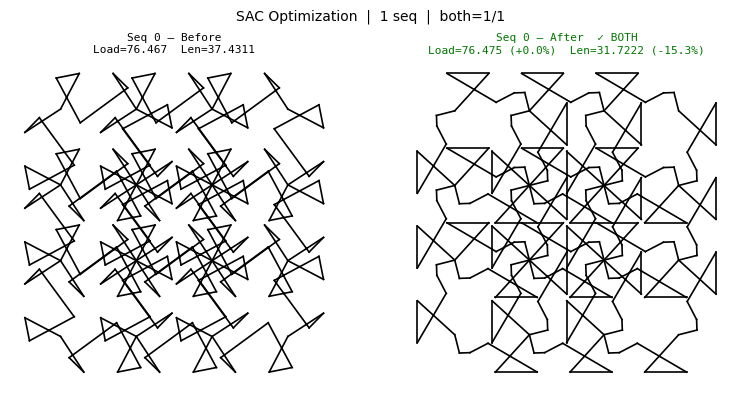

In [ ]:
"""
Quick_Start.ipynb — Cell 6: Before/after side-by-side visualisation
====================================================================

Renders each base encoding alongside its SAC-optimised counterpart so that
the relative load gain (Δw) and the relative material reduction (Δl) can be
inspected at a glance. The titles colour-code samples for which both
objectives strictly improved (the "BOTH" condition of §4.5).
"""

import matplotlib.pyplot as plt
import numpy as np

# Re-instantiate the surrogate stack independently of Cell 5 so this cell
# can be re-run without re-executing the optimisation loop.
_extractor = GraphFeatureExtractor()
_predictor = LoadPredictor(model_dir=r".\model", extractor=_extractor)
_builder   = GraphBuilder()

n_seq = len(all_results)
fig, axes = plt.subplots(n_seq, 2, figsize=(8, 4 * n_seq), squeeze=False)
fig.patch.set_facecolor("white")

for idx, rec in enumerate(all_results):
    base_p = np.array(rec["base"],   dtype=np.float32)
    opt_p  = np.array(rec["params"], dtype=np.float32)

    G_before = _builder.build(base_p)
    G_after  = _builder.build(opt_p)

    w_before = _predictor.predict_from_graph(G_before)
    l_before = total_edge_length(G_before)
    w_after  = rec["w"]
    l_after  = rec["l"]

    # Per-sample relative deltas, expressed in percent.
    dw = (w_after - w_before) / max(abs(w_before), 1e-6) * 100
    dl = (l_after - l_before) / max(abs(l_before), 1e-6) * 100

    for col, (G, label, w, l, delta) in enumerate([
        (G_before, "Before", w_before, l_before, None),
        (G_after,  "After",  w_after,  l_after,  (dw, dl)),
    ]):
        ax = axes[idx][col]
        ax.set_facecolor("white")
        pos = nx.get_node_attributes(G, "pos")
        for u, v in G.edges():
            ax.plot(
                [pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color="black", linewidth=1.2,
            )
        ax.set_aspect("equal")
        ax.axis("off")

        if delta is None:
            title = f"Seq {rec['seq_idx']} — {label}\nLoad={w:.3f}  Len={l:.4f}"
            color = "black"
        else:
            tag   = "  ✓ BOTH" if rec["both"] else ""
            title = (f"Seq {rec['seq_idx']} — {label}{tag}\n"
                     f"Load={w:.3f} ({dw:+.1f}%)  Len={l:.4f} ({dl:+.1f}%)")
            color = "#007700" if rec["both"] else "black"

        ax.set_title(title, fontsize=8, color=color, fontfamily="monospace", pad=4)

plt.suptitle(
    f"SAC Optimization  |  {n_seq} seq  |  "
    f"both={sum(r['both'] for r in all_results)}/{n_seq}",
    fontsize=10,
)
plt.tight_layout()

OBJ file size: 16.080078125 KB
total faces 350, quads 350, non-quad 0
graph nodes 352 edges 700
edges without face tag: 0
faces not referenced 4 times: 0
nodes 7352  edges 8400  all checks passed
nodes 7352  edges 8400  all checks passed


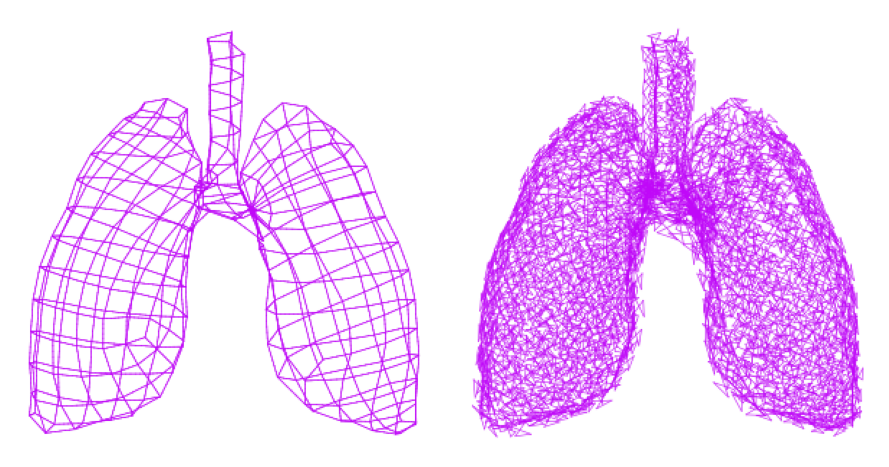

In [ ]:
"""
Quick_Start.ipynb — Cell 7: 3-D surface mapping onto a quad mesh
==================================================================

Demonstrator of the surface-mapping technique described in Section 4.6 of
the manuscript. The optimised 10-D encoding produced by Cell 5 is mapped
isomorphically onto every quadrilateral facet of a curved target surface
that has been pre-processed by QuadriFlow into an all-quad mesh, thereby
transferring the planar regular fibrous network architecture onto an
arbitrary 2-manifold.

Pipeline
--------
    (i)   QuadMesh: parse a Wavefront OBJ file emitted by QuadriFlow and
          construct the dual incidence map E -> (f₁, f₂) used by the
          deformer to build a smooth tangent/normal frame across shared
          edges (cf. §4.6 "encoding and deformation" stage).
    (ii)  MeshEdgeDeformer: for each edge-face pair, build a local
          orthonormal frame {e₁, e₂_in, e₂_out} from the face normal and
          the edge tangent, then displace the five interior control points
          along (e₁, e₂) using the optimised encoding. The sign of dy
          selects the in-plane vs out-of-plane normal so the deformation
          covers both sides of the manifold and reproduces the rotational
          replication scheme of the planar generator.
    (iii) GraphShot: orthographic projection-based renderer with a small
          basis of canonical viewpoints, used for figure preparation.

For full solid export (sphere-tube fattening + global rescale + OBJ
write-out as required for FDM/SLA fabrication), see ``Graph2OBJ.py`` —
this cell only performs the topology mapping and a flat-projection
preview.
"""

%matplotlib inline

import pathlib as _pp
import numpy as _np
import networkx as _nx
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tempfile
from collections import defaultdict, Counter
from pathlib import Path
from typing import Tuple, Union
from IPython.display import Image, display

OBJ_PATH = _pp.Path(r".\3_Lung_quad_400.obj")
assert OBJ_PATH.exists(), f"{OBJ_PATH} not found"
print("OBJ file size:", OBJ_PATH.stat().st_size / 1024, "KB")


class QuadMesh:
    """
    Minimal Wavefront-OBJ loader specialised for all-quad meshes.

    Builds two synchronised representations:
        * ``self.V``, ``self.F``  — vertex / face arrays in OBJ order;
        * ``self.G``               — NetworkX graph, with one node per
                                     vertex and a quad-cycle edge for each
                                     face. Non-quad faces are silently
                                     skipped, matching QuadriFlow's
                                     guarantee of an all-quad output.
    """

    def __init__(self, path):
        self.path = path; self.V = []; self.F = []; self.G = _nx.Graph()

    def parse_obj(self):
        for ln in self.path.open():
            if ln.startswith("v "):
                _, x, y, z = ln.split()
                self.V.append(_np.array([float(x), float(y), float(z)]))
            elif ln.startswith("f "):
                # OBJ uses 1-based indexing; strip any vt/vn suffixes.
                idx = [int(tok.split("/")[0]) - 1 for tok in ln.split()[1:]]
                self.F.append(idx)

    def build_graph(self):
        for i, p in enumerate(self.V):
            self.G.add_node(i, pos=p)
        for f in self.F:
            if len(f) != 4:
                continue
            self.G.add_edges_from([(f[j - 1], f[j]) for j in range(4)])

    def summary(self):
        n_face = len(self.F); n_quad = sum(len(f) == 4 for f in self.F)
        print(f"total faces {n_face}, quads {n_quad}, non-quad {n_face - n_quad}")
        print("graph nodes", self.G.number_of_nodes(), "edges", self.G.number_of_edges())


qm = QuadMesh(OBJ_PATH)
qm.parse_obj()
qm.build_graph()
qm.summary()

# ---------------------------------------------------------------------------
# Build the edge -> incident-faces map. In a closed orientable quad mesh
# every interior edge is incident to exactly two faces and every edge of
# every face is referenced exactly four times across all incident edges
# (each face has four edges, each contributing one reference). The two
# sanity checks below catch boundary holes and non-manifold defects in the
# QuadriFlow output before any deformation is attempted.
# ---------------------------------------------------------------------------
edge2faces = defaultdict(list)
for fid, f in enumerate(qm.F):
    if len(f) != 4:
        continue
    for a, b in ((f[0], f[1]), (f[1], f[2]), (f[2], f[3]), (f[3], f[0])):
        e = (a, b) if a < b else (b, a)
        edge2faces[e].append(fid)

qm.G.clear_edges()
for (u, v), fs in edge2faces.items():
    qm.G.add_edge(u, v, faces=tuple(fs))

missing_edges = [e for e, d in qm.G.edges.items() if not d["faces"]]
face_use      = Counter(fid for _, _, d in qm.G.edges(data=True) for fid in d["faces"])
wrong_faces   = [fid for fid, c in face_use.items() if c != 4]
print("edges without face tag:", len(missing_edges))
print("faces not referenced 4 times:", len(wrong_faces))


class MeshEdgeDeformer:
    """
    Encoding-driven displacement of every quad-edge interior point.

    For each (edge, face) pair the deformer constructs the local
    orthonormal frame
        e₁     = tangent along the edge (oriented by face winding),
        e₂_in  = e₁ × n_face         (in-plane normal),
        e₂_out = e₁ × n_avg          (out-of-plane normal, smoothed
                                       across the two incident faces),
    and displaces the five interior control points by
        p_k = p_u + t_k · L · e₁
                  + dx_k · L · e₁
                  + dy_k · L · (e₂_out if dy_k > 0 else e₂_in).
    The sign-dependent choice of e₂ ensures the network alternates between
    inward and outward stacking, mirroring the planar two-sided regulation
    discussed in §4.1.

    A topological invariant is enforced as a post-condition: every face
    must end up referenced exactly ``SEG_PER_FACE = 4 · (k+1)`` times by
    edge segments after subdivision.
    """

    def __init__(self, qm, disp5=None):
        self.qm         = qm
        self.disp5      = disp5 if disp5 is not None else [(0, 0)] * 5
        self.V          = np.asarray(qm.V)
        self.Fn         = [self._quad_normal(q) for q in qm.F]
        self.edge_faces = edge2faces
        self.N_SEG_EDGE  = len(self.disp5) + 1
        self.SEG_PER_FACE = 4 * self.N_SEG_EDGE
        self.G          = nx.Graph()
        for vid, p in enumerate(self.V):
            self.G.add_node(vid, pos=p)
        self.next_pid   = len(self.V)

    def _unit(self, v):
        n = np.linalg.norm(v); return v / n if n else v

    def _quad_normal(self, quad):
        """Right-hand-rule unit normal of a quad, computed from the first
        two non-collinear edge vectors."""
        a, b, c, _ = self.V[quad]; return self._unit(np.cross(b - a, c - a))

    def _orient_edge(self, fid, a, b):
        """Return (a, b) in the order matching the winding of face fid."""
        q = self.qm.F[fid]
        for i in range(4):
            if q[i] == a and q[(i + 1) % 4] == b: return a, b
            if q[i] == b and q[(i + 1) % 4] == a: return b, a
        raise RuntimeError

    def _add_inner_points(self, fid, u0, v0, faces_lst):
        u, v     = self._orient_edge(fid, u0, v0)
        p_u, p_v = self.V[u], self.V[v]
        Lvec     = p_v - p_u; L = np.linalg.norm(Lvec)
        e1       = self._unit(Lvec)
        n_face   = self.Fn[fid]
        # Smooth the normal across the shared edge to avoid creasing
        # artefacts near sharp dihedral angles.
        if len(faces_lst) == 2:
            fid2  = faces_lst[0] if faces_lst[1] == fid else faces_lst[1]
            n_avg = self._unit(n_face + self.Fn[fid2])
        else:
            n_avg = n_face
        e2_in  = self._unit(np.cross(n_face, e1))
        e2_out = self._unit(np.cross(n_avg,  e1))
        inner  = []
        for k, (dx, dy) in enumerate(self.disp5, 1):
            t    = k / (len(self.disp5) + 1)
            base = p_u + t * Lvec
            e2   = e2_out if dy > 0 else e2_in
            pos  = base + dx * L * e1 + dy * L * e2
            pid  = self.next_pid; self.next_pid += 1
            self.G.add_node(pid, pos=pos)
            inner.append(pid)
        seq = [u] + inner + [v]
        for a, b in zip(seq[:-1], seq[1:]):
            self.G.add_edge(a, b, faces=(fid,))

    def build(self):
        for u, v, d in self.qm.G.edges(data=True):
            faces_lst = d["faces"]
            for fid in faces_lst:
                self._add_inner_points(fid, u, v, faces_lst)

    def _check_segments(self):
        """Topological invariant: each face must be referenced exactly
        ``SEG_PER_FACE`` times by post-subdivision edge segments."""
        cnt = Counter(fid for _, _, d in self.G.edges(data=True) for fid in d["faces"])
        bad = [fid for fid, c in cnt.items() if c != self.SEG_PER_FACE]
        if bad: raise RuntimeError(f"Segment count error on faces {bad[:10]}")
        print(f"nodes {self.G.number_of_nodes()}  edges {self.G.number_of_edges()}  all checks passed")

    def run(self):
        self.build()
        self._check_segments()
        return self.G


class GraphShot:
    """
    Orthographic-projection screenshot utility for 3-D fibrous networks.

    Maps a 3-D NetworkX graph onto a 2-D image plane defined by a
    user-selected canonical view direction and an in-plane roll angle, then
    rasterises every edge as a thin polyline. Used here for the
    before/after preview only; the high-fidelity solid export is delegated
    to the Graph2OBJ utility.
    """

    EDGE_COLOR = "#C008F8"
    PRESETS = {
        "iso": (np.array([1.0, 1.0, 1.0]),  np.array([0.0, 0.0, 1.0])),
        "+x":  (np.array([1.0, 0.0, 0.0]),  np.array([0.0, 0.0, 1.0])),
        "-x":  (np.array([-1.0, 0.0, 0.0]), np.array([0.0, 0.0, 1.0])),
        "+y":  (np.array([0.0, 1.0, 0.0]),  np.array([0.0, 0.0, 1.0])),
        "-y":  (np.array([0.0, -1.0, 0.0]), np.array([0.0, 0.0, 1.0])),
        "+z":  (np.array([0.0, 0.0, 1.0]),  np.array([0.0, 1.0, 0.0])),
        "-z":  (np.array([0.0, 0.0, -1.0]), np.array([0.0, 1.0, 0.0])),
    }

    def __init__(self, G: nx.Graph, view: str, *, roll_deg: float = 0.0,
                 zoom: float = 1.0, img_size: Tuple[int, int] = (400, 400),
                 out_path: Union[str, Path]):
        self.view      = view
        self.roll_deg  = roll_deg
        self.zoom      = zoom
        self.img_size  = img_size
        self.out_path  = Path(out_path)
        order          = sorted(G.nodes())
        self.node_idx  = {n: i for i, n in enumerate(order)}
        self.pts       = np.asarray([G.nodes[n]["pos"] for n in order], float)
        self.edges     = [(self.node_idx[u], self.node_idx[v]) for u, v in G.edges()]

    def _project(self):
        """Construct an orthonormal screen basis (right, up_orth) such that
        the view direction d is normal to the image plane, then project the
        3-D vertex set and apply the roll rotation in screen space."""
        d_raw, up_raw = self.PRESETS[self.view]
        d   = d_raw  / np.linalg.norm(d_raw)
        up  = up_raw / np.linalg.norm(up_raw)
        right = np.cross(up, d)
        if np.linalg.norm(right) < 1e-10:
            right = np.array([1.0, 0.0, 0.0])
        right  = right / np.linalg.norm(right)
        up_orth = np.cross(d, right)
        up_orth = up_orth / np.linalg.norm(up_orth)
        sx = self.pts @ right
        sy = self.pts @ up_orth
        rad = np.deg2rad(self.roll_deg)
        c, s = np.cos(rad), np.sin(rad)
        return c * sx - s * sy, s * sx + c * sy

    def shoot(self, show_png: bool = True):
        sx, sy = self._project()
        dpi    = 100
        w, h   = self.img_size
        fig, ax = plt.subplots(figsize=(w / dpi, h / dpi), dpi=dpi)
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")
        for ui, vi in self.edges:
            ax.plot([sx[ui], sx[vi]], [sy[ui], sy[vi]],
                    color=self.EDGE_COLOR, linewidth=0.4, rasterized=True)
        ax.set_aspect("equal")
        ax.axis("off")
        fig.savefig(str(self.out_path), dpi=dpi, bbox_inches="tight",
                    facecolor="white", pad_inches=0)
        plt.close(fig)
        if show_png:
            display(Image(filename=self.out_path))
        return self.out_path


# ---------------------------------------------------------------------------
# Driver: pull the best optimised encoding from Cell 5, deform the loaded
# quad mesh under both the zero-displacement reference and the optimised
# encoding, and render a side-by-side preview.
# ---------------------------------------------------------------------------
VIEW, ROLL, ZOOM = "-z", 0, 1.5

rec       = all_results[0]
opt_p     = np.array(rec["params"], dtype=np.float64)
disp5_opt = [(float(opt_p[2 * i]), float(opt_p[2 * i + 1])) for i in range(5)]

with tempfile.TemporaryDirectory() as _tmp:
    tmp = Path(_tmp)

    # Reference (zero-displacement) mapping.
    d0 = MeshEdgeDeformer(qm, disp5=[(0.0, 0.0)] * 5)
    G0 = d0.run()
    GraphShot(G0, view=VIEW, roll_deg=ROLL, zoom=ZOOM,
              img_size=(400, 400), out_path=tmp / "zero.png").shoot(show_png=False)

    # SAC-optimised mapping.
    d1 = MeshEdgeDeformer(qm, disp5=disp5_opt)
    G1 = d1.run()
    GraphShot(G1, view=VIEW, roll_deg=ROLL, zoom=ZOOM,
              img_size=(400, 400), out_path=tmp / "opt.png").shoot(show_png=False)

    img0 = mpimg.imread(str(tmp / "zero.png"))
    img1 = mpimg.imread(str(tmp / "opt.png"))

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
fig.patch.set_facecolor("white")

axes[0].imshow(img0); axes[0].axis("off")
axes[1].imshow(img1); axes[1].axis("off")

plt.tight_layout()